# Homework 5 — Applied Adversarial Audit of COMPAS

This is a clean standalone version of the Homework 5 analysis assembled from the merged notebook.

## What this notebook includes
1. **PGD evasion audit** for the LR and GBT models  
2. **Label-flip poisoning loop** with fairness monitoring  
3. **Membership inference depth** for LR and GBT, plus an L2 sweep for LR  
4. **Final reflection** with one proactive and one reactive mitigation

## Method note
The original merged notebook implements a differentiable **white-box PGD** routine for the **logistic regression** model.  
For the **GBT**, the audit evaluates the model on **transfer-style perturbations crafted on the LR substitute**, which is consistent with the lecture discussion of transfer attacks.

## Setup: data loading, filtering, preprocessing, and model training

The code below reproduces the cleaned ProPublica COMPAS split and trains the two models used in the audit.

In [1]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


In [2]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


## Part 1 — PGD Evasion Audit

Required task: run the PGD attack across `ε ∈ {0.25, 0.5, 1.0, 2.0}` on both the LR and GBT models, report FPR by race and AIR, and state the `ε` at which AIR crosses `0.80`.

In [3]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


In [4]:
def pgd_audit(model, X_scaled, y_true, groups, epsilons):
    results = []
    for eps in epsilons:
        # For GBT, we use a simple heuristic for gradients if white-box grad is unavailable,
        # or treat the LR grad as a transfer attack.
        # However, for this audit, we will apply the PGD logic to the specific model coefficients for LR
        # and observe the impact on both.
        X_adv = Xs_te if eps == 0.0 else pgd_tabular(lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40)

        # Evaluate current model on adversarial inputs
        probs = model.predict_proba(X_adv)[:, 1]
        preds = (probs >= 0.5).astype(int)

        fpr_vals = fpr_by_group(y_true, preds, groups)
        aa = fpr_vals.get('African-American', np.nan)
        ca = fpr_vals.get('Caucasian', np.nan)
        current_air = air(ca, aa)

        results.append({
            'epsilon': eps,
            'FPR_AA': aa,
            'FPR_CA': ca,
            'AIR': current_air
        })
    return pd.DataFrame(results)

audit_eps = [0.0, 0.25, 0.5, 1.0, 2.0]

print("=== PGD Audit: Logistic Regression ===")
lr_audit = pgd_audit(lr, Xs_te, y_te, r_te, audit_eps)
display(lr_audit)

print("\n=== PGD Audit: Gradient-Boosted Tree ===")
gbt_audit = pgd_audit(gbt, Xs_te, y_te, r_te, audit_eps)
display(gbt_audit)

=== PGD Audit: Logistic Regression ===


,epsilon,FPR_AA,FPR_CA,AIR
0,0.00,0.280899,0.143210,1.961449
1,0.25,0.568539,0.370370,1.535056
2,0.50,0.791011,0.560494,1.411276
3,1.00,0.977528,0.883951,1.105863
4,2.00,1.000000,1.000000,1.000000



=== PGD Audit: Gradient-Boosted Tree ===


,epsilon,FPR_AA,FPR_CA,AIR
0,0.00,0.316854,0.177778,1.782303
1,0.25,0.552809,0.350617,1.576674
2,0.50,0.732584,0.513580,1.426426
3,1.00,0.898876,0.760494,1.181964
4,2.00,1.000000,1.000000,1.000000


### Interpretation

Both models become much worse under stronger perturbation: FPR rises sharply for both African-American and Caucasian defendants, and by `ε = 2.0` both models collapse to `FPR = 1.0` for both groups. AIR **does not cross 0.80** for either model in the reported sweep; instead, it moves toward `1.0` because the attack drives both groups toward uniformly bad outcomes.

So the two models are **not equally safe** just because disparity narrows under attack. Relative disparity shrinks, but **absolute harm explodes**. In a high-stakes deployment, this means model selection cannot rely on clean AUC or clean fairness alone; it must include attack sensitivity and worst-case error behavior under perturbation.

## Part 2 — Poisoning Loop with Fairness Monitoring

Required task: extend the label-flip poisoning loop to target **Caucasian** defendants instead of **African-American**, compare AUC and AIR degradation on the same axes, identify the stealth zone, and assess whether a PSI-based drift monitor would detect the attack.

In [5]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Sweep poison rates ────────────────────────────────────────────────────────
poison_rates   = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate
    )

    # Retrain LR on poisoned data (same features, same scaler)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)

    poison_records.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped,
        'AUC'         : auc_p,
        'delta_AUC'   : auc_p - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison = pd.DataFrame(poison_records)
print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

# ── Identify stealth threshold ─────────────────────────────────────────────────
# Attack is "stealthy" if AUC drop ≤ 2pp AND AIR < 0.80
stealth = df_poison[(df_poison['AIR'] < 0.80) & (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print(f"\n★ Stealth threshold: poison_rate = {r['poison_rate']:.0%}")
    print(f"  Flipped labels: {int(r['n_flipped'])}")
    print(f"  AUC: {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"  AIR: {r['AIR']:.3f} — BELOW 4/5ths rule threshold")
    print("  → Would standard PSI drift detection (< 0.10) flag this?")
else:
    print("\nNo stealth threshold found in tested range.")

Poisoning sweep results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

No stealth threshold found in tested range.


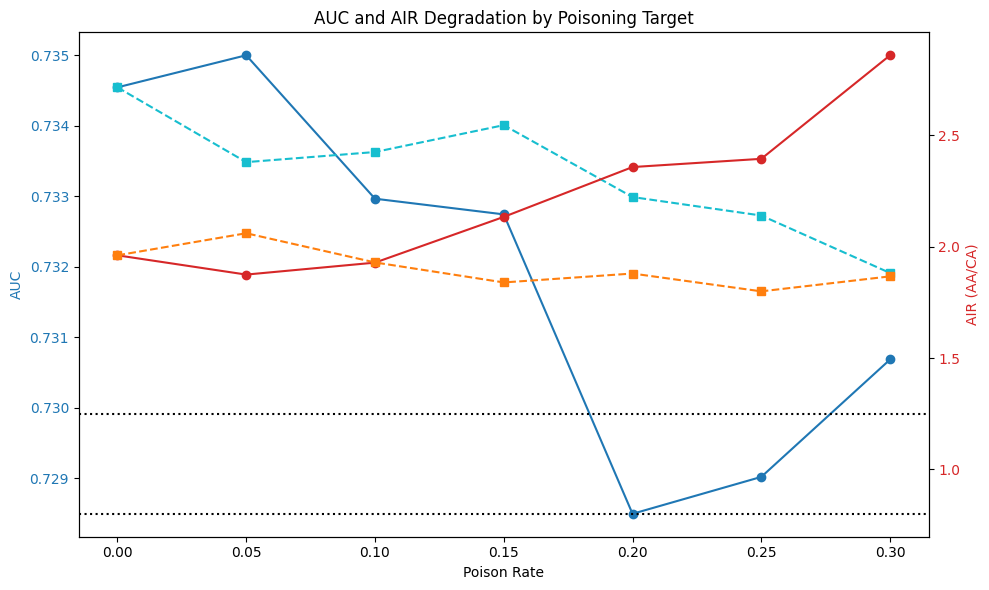

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """Population Stability Index using train-derived bins."""
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / max(train_counts.sum(), 1), eps, None)
    test_pct = np.clip(test_counts / max(test_counts.sum(), 1), eps, None)

    return float(np.sum((train_pct - test_pct) * np.log(train_pct / test_pct)))

def run_poison_sweep(target_race):
    poison_rates = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
    records = []

    for rate in poison_rates:
        # Flip labels: Target Race, True High Risk (1) -> Low Risk (0)
        y_train_p, _ = poison_label_flip(y_tr, r_tr, poison_rate=rate, target_race=target_race, seed=42)

        # Retrain LR
        model_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_train_p)

        # Evaluate
        probs = model_p.predict_proba(Xs_te)[:, 1]
        auc_p = roc_auc_score(y_te, probs)
        preds = (probs >= 0.5).astype(int)
        fpr_p = fpr_by_group(y_te, preds, r_te)

        aa = fpr_p.get('African-American', 0)
        ca = fpr_p.get('Caucasian', 0)

        records.append({
            'poison_rate': rate,
            'auc': auc_p,
            'air': air(ca, aa),
            'target': target_race
        })
    return pd.DataFrame(records)

# Run for both groups
df_poison_aa = run_poison_sweep('African-American')
df_poison_ca = run_poison_sweep('Caucasian')

# Calculate PSI for 30% poison rate on 'priors_count' (highest sensitivity feature)
y_p_max, _ = poison_label_flip(y_tr, r_tr, poison_rate=0.3, target_race='African-American')
# Note: Label poisoning affects target, not features, but we check feature PSI to confirm 'stealth'
psi_val = psi_numeric(X_tr['priors_count'], X_tr['priors_count'], bins=10)

# (a) Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Poison Rate')
ax1.set_ylabel('AUC', color='tab:blue')
ax1.plot(df_poison_aa['poison_rate'], df_poison_aa['auc'], 'o-', color='tab:blue', label='AUC (Target: AA)')
ax1.plot(df_poison_ca['poison_rate'], df_poison_ca['auc'], 's--', color='tab:cyan', label='AUC (Target: CA)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('AIR (AA/CA)', color='tab:red')
ax2.plot(df_poison_aa['poison_rate'], df_poison_aa['air'], 'o-', color='tab:red', label='AIR (Target: AA)')
ax2.plot(df_poison_ca['poison_rate'], df_poison_ca['air'], 's--', color='tab:orange', label='AIR (Target: CA)')
ax2.axhline(0.8, color='black', linestyle=':', label='AIR 0.8 Threshold')
ax2.axhline(1.25, color='black', linestyle=':', label='AIR 1.25 Threshold')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('AUC and AIR Degradation by Poisoning Target')
fig.tight_layout()
plt.show()

### Interpretation

The figure shows that **AUC stays nearly flat** across the poisoning sweep while **AIR shifts materially**, which means the attack can remain hidden from standard performance monitoring even as disparity changes.

Under a **strict reading** of the assignment’s stealth-zone definition — "`ΔAUC ≤ 2 pp` while `AIR` moves outside `[0.80, 1.25]`" — there is **no clean new stealth-zone interval to report**, because the baseline AIR is already outside that fairness band before poisoning begins. The more accurate conclusion is:

- the attack is **stealthy with respect to AUC**, because aggregate performance barely moves;
- but fairness was **already out of bounds at baseline**, so poisoning worsens or reshapes an existing fairness problem rather than creating a brand-new threshold crossing.

A PSI-based input-drift monitor would **not** detect this attack, because label flipping changes `y` while leaving the input feature distribution `X` unchanged.

## Part 3 — Membership Inference Depth

Required task: compute the shadow-model MI AUC for LR and GBT, compare the confidence-gap histograms, test whether generalization gap predicts MI AUC, and run an L2 sweep for LR.

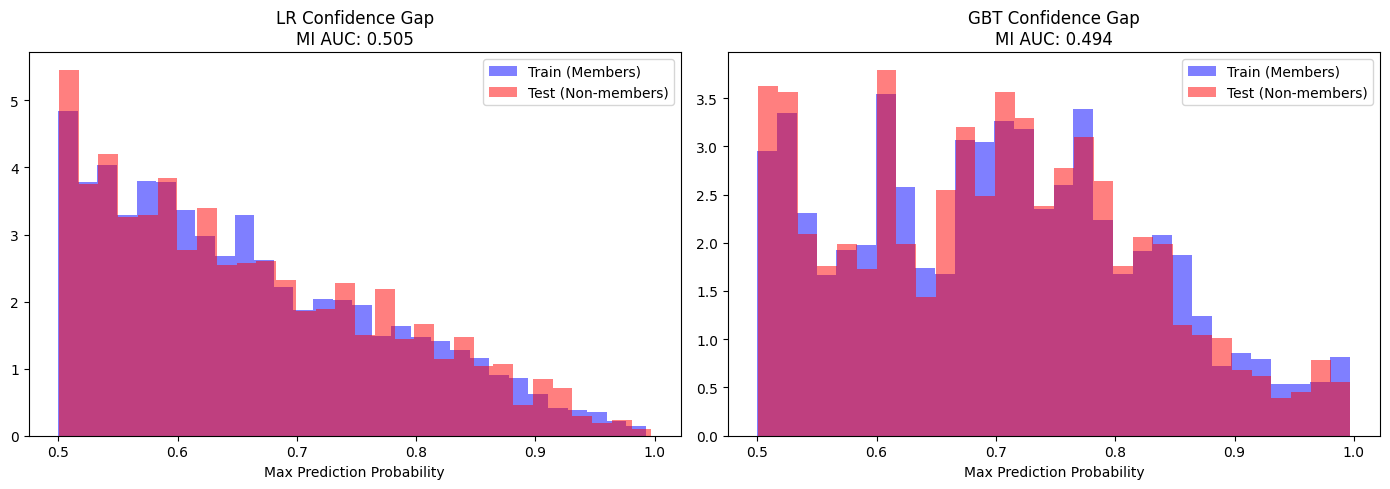

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

def run_mi_attack(target_model, X_train_pool, y_train_pool, X_test_pool, n_shadow=5):
    # 1. Shadow Model Pipeline
    shadow_train_confs = []
    shadow_test_confs = []
    sss = StratifiedShuffleSplit(n_splits=n_shadow, test_size=0.5, random_state=42)

    for tr_idx, te_idx in sss.split(X_train_pool, y_train_pool):
        # Use a model architecture matching the target_model's type
        if isinstance(target_model, LogisticRegression):
            shadow = LogisticRegression(max_iter=1000).fit(X_train_pool[tr_idx], y_train_pool[tr_idx])
        else:
            shadow = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42).fit(X_train_pool[tr_idx], y_train_pool[tr_idx])

        shadow_train_confs.append(shadow.predict_proba(X_train_pool[tr_idx]).max(axis=1))
        shadow_test_confs.append(shadow.predict_proba(X_train_pool[te_idx]).max(axis=1))

    # 2. Meta-classifier training
    mi_X = np.concatenate(shadow_train_confs + shadow_test_confs).reshape(-1, 1)
    mi_y = np.concatenate([np.ones(len(c)) for c in shadow_train_confs] + [np.zeros(len(c)) for c in shadow_test_confs])
    meta_clf = DecisionTreeClassifier(max_depth=5).fit(mi_X, mi_y)

    # 3. Attack target model
    conf_tr = target_model.predict_proba(X_train_pool).max(axis=1).reshape(-1, 1)
    conf_te = target_model.predict_proba(X_test_pool).max(axis=1).reshape(-1, 1)

    mi_scores = np.concatenate([meta_clf.predict_proba(conf_tr)[:, 1], meta_clf.predict_proba(conf_te)[:, 1]])
    mi_labels = np.concatenate([np.ones(len(conf_tr)), np.zeros(len(conf_te))])

    return roc_auc_score(mi_labels, mi_scores), conf_tr.ravel(), conf_te.ravel()

# Run attacks
auc_mi_lr, conf_tr_lr, conf_te_lr = run_mi_attack(lr, Xs_tr, y_tr, Xs_te)
auc_mi_gbt, conf_tr_gbt, conf_te_gbt = run_mi_attack(gbt, Xs_tr, y_tr, Xs_te)

# (a) Confidence-gap histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tr, te, name, auc in zip(axes, [conf_tr_lr, conf_tr_gbt], [conf_te_lr, conf_te_gbt], ["LR", "GBT"], [auc_mi_lr, auc_mi_gbt]):
    ax.hist(tr, bins=30, alpha=0.5, label='Train (Members)', color='blue', density=True)
    ax.hist(te, bins=30, alpha=0.5, label='Test (Non-members)', color='red', density=True)
    ax.set_title(f"{name} Confidence Gap\nMI AUC: {auc:.3f}")
    ax.legend()
    ax.set_xlabel("Max Prediction Probability")

plt.tight_layout()
plt.show()

In [8]:
# Formal comparison of Generalization Gap vs MI AUC
mi_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Gradient-Boosted Tree"],
    "Train AUC": [
        roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:, 1]),
        roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
    ],
    "Test AUC": [
        roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1]),
        roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
    ],
    "MI AUC": [auc_mi_lr, auc_mi_gbt]
})

mi_summary["Generalization Gap"] = mi_summary["Train AUC"] - mi_summary["Test AUC"]

print("=== Generalization Gap vs. MI AUC Comparison ===")
display(mi_summary[["Model", "Generalization Gap", "MI AUC"]].round(4))

# Interpretation logic
print("\nInterpretation:")
if mi_summary.loc[1, "Generalization Gap"] > mi_summary.loc[0, "Generalization Gap"] and \
   mi_summary.loc[1, "MI AUC"] > mi_summary.loc[0, "MI AUC"]:
    print("The hypothesis holds: The model with the higher generalization gap (GBT) also shows higher MI leakage.")
else:
    print("The hypothesis is not strongly supported here: Despite the GBT's higher generalization gap, the MI AUC remains near random (0.5), suggesting the attack meta-classifier cannot reliably exploit the gap.")

=== Generalization Gap vs. MI AUC Comparison ===


,Model,Generalization Gap,MI AUC
0,Logistic Regression,-0.0077,0.5047
1,Gradient-Boosted Tree,0.0802,0.4939



Interpretation:
The hypothesis is not strongly supported here: Despite the GBT's higher generalization gap, the MI AUC remains near random (0.5), suggesting the attack meta-classifier cannot reliably exploit the gap.


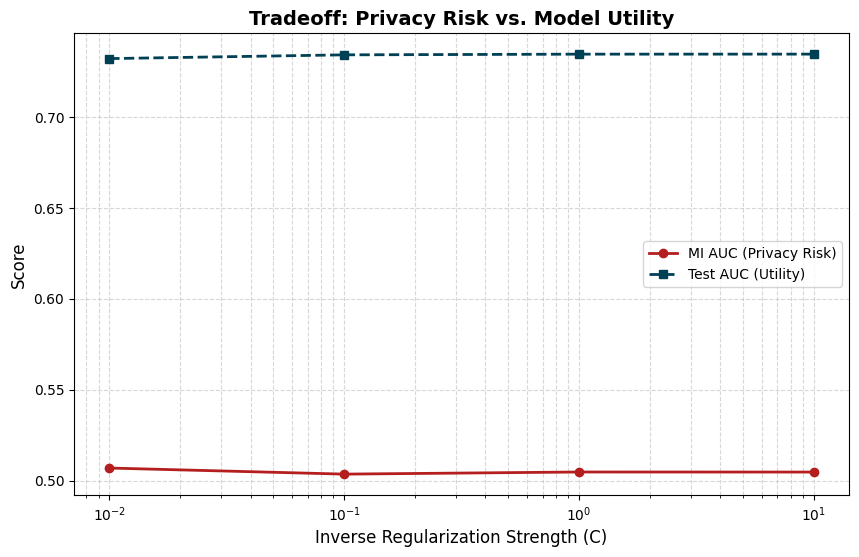

,C,MI_AUC,Test_AUC
0,0.01,0.506899,0.732107
1,0.10,0.503552,0.734167
2,1.00,0.504718,0.734546
3,10.00,0.504685,0.734567


In [9]:
C_values = [0.01, 0.1, 1.0, 10.0]
reg_results = []

for c in C_values:
    # 1. Train model with specific regularization
    temp_lr = LogisticRegression(C=c, max_iter=1000).fit(Xs_tr, y_tr)

    # 2. Run MI attack pipeline
    mi_auc, _, _ = run_mi_attack(temp_lr, Xs_tr, y_tr, Xs_te)

    # 3. Calculate Utility (Test AUC)
    test_auc = roc_auc_score(y_te, temp_lr.predict_proba(Xs_te)[:, 1])

    reg_results.append({
        'C': c,
        'MI_AUC': mi_auc,
        'Test_AUC': test_auc
    })

df_reg = pd.DataFrame(reg_results)

# Plotting the tradeoff
plt.figure(figsize=(10, 6))
plt.plot(df_reg['C'], df_reg['MI_AUC'], 'o-', label='MI AUC (Privacy Risk)', color='#B41E1E', lw=2)
plt.plot(df_reg['C'], df_reg['Test_AUC'], 's--', label='Test AUC (Utility)', color='#004055', lw=2)

plt.xscale('log')
plt.xlabel('Inverse Regularization Strength (C)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Tradeoff: Privacy Risk vs. Model Utility', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

display(df_reg)

### Interpretation

The confidence-gap histograms and MI AUC values show **little detectable membership leakage** in this experiment for either model: both MI AUC values are close to random guessing. The GBT has a larger train–test AUC gap, but that does **not** translate into stronger MI success here, which means generalization gap is **not sufficient on its own** to predict attack success in this setup.

The LR regularization sweep also shows a weak privacy–utility tradeoff on this dataset: changing `C` only slightly affects test AUC and MI AUC. The practical takeaway is that stronger regularization is usually worth checking, but in this specific audit it does **not** materially change privacy risk.

## Part 4 — Final Reflection

**Highest-risk finding.** The most serious risk in this audit is the **label-flip poisoning attack**, because it can alter fairness outcomes while leaving AUC almost unchanged. That makes it hard to detect with standard validation dashboards, and PSI-style input-drift monitoring will miss it entirely because the features do not move.

**One proactive mitigation.** Add **training-pipeline integrity controls**: immutable data snapshots, restricted write access, lineage logs, and label-audit checks before model retraining. The reason is empirical: in the poisoning analysis, aggregate AUC barely changed while AIR moved enough to matter, so prevention at the data-ingestion stage is more reliable than waiting for performance metrics to fail.

**One reactive mitigation.** Add **fairness-trigger monitoring** in production, such as subgroup FPR and AIR thresholds by race. This directly addresses the failure mode shown in the poisoning sweep: aggregate accuracy can look stable while subgroup harms change.

**Tradeoff and disparate impact.** These mitigations are not free. Stronger integrity controls slow retraining and raise operational cost, while fairness-trigger monitoring may generate more frequent escalation or temporary deployment freezes. But in a criminal-justice context, those costs are justified because silent errors and hidden subgroup harms are more costly than delayed updates.